# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, current_beam):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - current_beam**2)
    final_bmin_as = np.sqrt(bmin_as**2 - current_beam**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def calculate_resolution2( clean_beam, current_beam):
    from radio_beam import Beam
    bmaj_clean = clean_beam['bmaj']
    bmin_clean = clean_beam['bmin']
    bpa_deg_clean = clean_beam['beam_pa']

    bmaj_current = current_beam['bmaj']
    bmin_current = current_beam['bmin']
    bpa_deg_current = current_beam['beam_pa']

    beam_orig =  Beam(major=bmaj_current*u.arcsec, minor=bmin_current*u.arcsec, pa=bpa_deg_current)
    beam_target = Beam(major=bmaj_clean*u.arcsec, minor=bmin_clean*u.arcsec, pa=bpa_deg_clean)

    beam_final = beam_target.deconvolve(beam_orig)

    #return values in a dict
    final_resolution = {'bmaj': beam_final.major.to(u.arcsec).value,
                        'bmin': beam_final.minor.to(u.arcsec).value,
                        'beam_pa': beam_final.pa.to(u.deg).value}

    return final_resolution


In [7]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [8]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

# Data

In [11]:
# UVtable
dir = "../../data/uvtable/"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Load data
file = np.loadtxt(data_file, unpack = True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [12]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [13]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [14]:
Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [16]:
imsize = N

In [17]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [18]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [19]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

In [20]:
frank2d = Frank2D(imsize, Rmax)

In [21]:
start_time = time.time()
frank2d.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.09  min |  5.42 seconds
        +  Building system = 0.09  min |  5.55 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [01:02<3:05:03,  4.48 iterations/s]


            +  BiCGStab = 1.05  min |  62.75 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.24  min |  14.33 seconds
--> times building full visibility model = 0.24  min |  14.37 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 took 90.3668897151947 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [22]:
Plot_ = Plot(frank2d, geom_f2d)

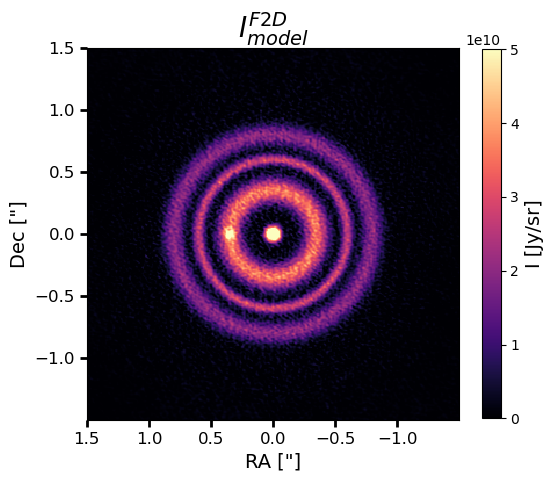

In [23]:
Plot_.intensity(gamma=1, zoom=2, vmax = 5e10)

### Open fits file
Of image regridded in CASA with imregrid, the same image from where we got the CLEAN model uvtable.

In [27]:
from astropy.io import fits
dir_  = "../../data/dotimage_fits/"
disk = 'SimulatedBlob_dotimage_imsize642_cellsize0p009.fits'

fits_name = dir_ + disk

In [28]:
hdul = fits.open(fits_name)

In [29]:
import matplotlib.colors as colors

### CLEAN model imregridded

In [30]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [31]:
hdr = hdul[0].header
data = hdul[0].data 

In [32]:
# beam
bmaj = hdr.get('BMAJ') # degrees
bmaj_as = bmaj * 3600 # arcseconds
bmin = hdr.get('BMIN')
bmin_as = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [33]:
w = WCS(hdr)

In [34]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 642, 642) -> squeezed: (642, 642)


In [35]:
data = data_squeezed

In [36]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [37]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



In [38]:
cellsize_clean = np.abs(ra_off_arcsec[0][1]-ra_off_arcsec[0][0])

In [39]:
pixel_scale_x_as = cellsize_clean
pixel_scale_y_as = cellsize_clean

bmaj_pix = bmaj_as/pixel_scale_x_as
bmin_pix = bmin_as/pixel_scale_y_as
angle_display = 90.0 - bpa 

In [40]:
rout*2 / imsize  

0.003115264797507788

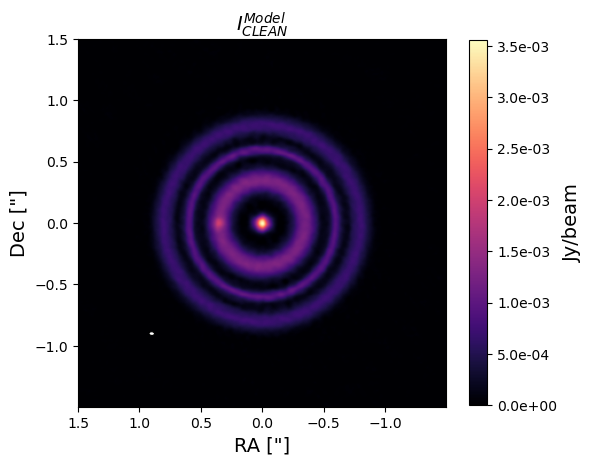

In [41]:
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max())
ax = plt.gca()

im = ax.imshow(
    img,
    extent=[xmax, xmin, ymax, ymin],
    aspect='equal',
    cmap='magma',
    norm=norm,
)

ax.set_xlabel('RA ["]', size=14)
ax.set_ylabel('Dec ["]', size=14)
ax.set_xlim(xmax/2, xmin/2)
ax.set_ylim(ymax/2, ymin/2)
ax.set_title(r'$I^{Model}_{CLEAN}$', size=14)

cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label( hdr.get('BUNIT'), size=14)
cbar.formatter = FuncFormatter(lambda x, pos: f"{x:.1e}")
cbar.update_ticks()
ax.grid(False)

xloc = xmin + 0.5 * (xmax - xmin)
yloc = ymin + 0.5 * (ymax - ymin)


beam = patches.Ellipse(
    (0.9, -0.9), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [42]:
# arcsecs per pixel
cell = np.abs(ra_off_arcsec[0][1] -ra_off_arcsec[0][0])

### Convolve f2d

In [43]:
I_f2d = frank2d.intensity_model

In [44]:
I_f2d.shape 

(642, 642)

**Jy/sr $\implies$ Jy/beam**

In [45]:
FHWM_maj = bmaj_as / rad_to_arcsec
FHWM_min = bmin_as / rad_to_arcsec
omega = ( np.pi / 4 * np.log(2) ) * FHWM_maj * FHWM_min
I_f2d_Jybeam = I_f2d * omega

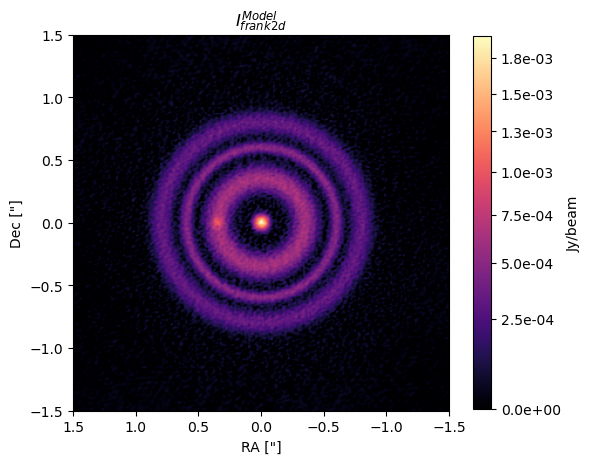

In [67]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell


plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.7, vmin=0, vmax = I_f2d_Jybeam.max())
ax = plt.gca()

im = ax.imshow(
    I_f2d_Jybeam,
    extent=[xmax, xmin, ymax, ymin],
    aspect='equal',
    cmap='magma',
    norm=norm,
)

ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_xlim(xmax/2, xmin/2)
ax.set_ylim(ymax/2, ymin/2)
ax.set_title(r'$I^{Model}_{frank2d}$')

cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label('Jy/beam')
cbar.formatter = FuncFormatter(lambda x, pos: f"{x:.1e}")
cbar.update_ticks()
ax.grid(False)

xloc = xmin + 0.5 * (xmax - xmin)
yloc = ymin + 0.5 * (ymax - ymin)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Convolution**

In [59]:
FWHM_frank2d = 23e-3

In [60]:
# defining beams
from radio_beam import Beam
beam_orig =  Beam(major=FWHM_frank2d*u.arcsec, minor=FWHM_frank2d*u.arcsec, pa=0)
beam_target = Beam(major=bmaj_as*u.arcsec, minor=bmin_as*u.arcsec, pa=hdr['BPA']*u.deg)

In [61]:
# calculating convolution beam
conv_beam = beam_target.deconvolve(beam_orig)

In [62]:
recon_beam = conv_beam.convolve(beam_orig)
print("reconvolved: ", recon_beam)

reconvolved:  Beam: BMAJ=0.0446064434952489 arcsec BMIN=0.0300071798270122 arcsec BPA=85.91123199462999 deg


In [63]:
# creating kernel in pixels
from astropy.convolution import convolve_fft, Gaussian2DKernel
pixscale = cellsize_clean
sigma_conv_pix = (conv_beam.major / (2.355 * pixscale)).decompose().value
kernel = Gaussian2DKernel(sigma_conv_pix)

In [64]:
cellsize_clean

0.00934582909954429

In [65]:
# convolve
I_f2d_Jybeam_conv = convolve_fft(I_f2d_Jybeam, kernel, boundary='wrap')

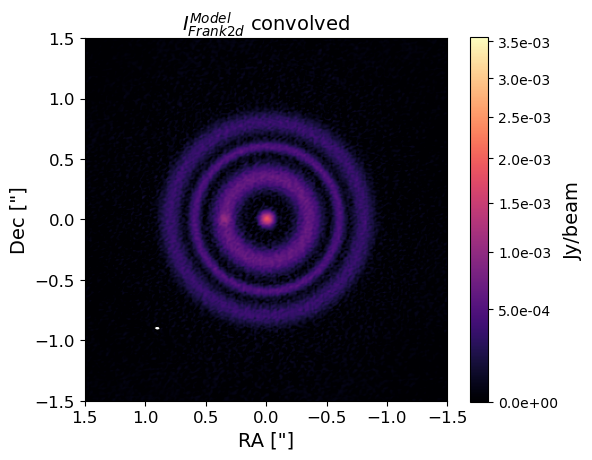

In [68]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell

plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.7, vmin=0, vmax = img.max())
ax = plt.gca()

im = ax.imshow(
    I_f2d_Jybeam_conv,
    extent=[xmax, xmin, ymax, ymin],
    aspect='equal',
    cmap='magma',
    norm=norm,
)

ax.set_xlabel('RA ["]', size = 14)
ax.set_ylabel('Dec ["]', size = 14)
ax.set_xlim(xmax/2, xmin/2)
ax.set_ylim(ymax/2, ymin/2)
ax.set_title(r'$I^{Model}_{Frank2d}$ convolved', size = 14)
plt.tick_params(axis='both', labelsize=12)


cbar = plt.colorbar(im, ax=ax,shrink =0.9)
cbar.set_label('Jy/beam', size=14)
cbar.formatter = FuncFormatter(lambda x, pos: f"{x:.1e}")
cbar.update_ticks()
ax.grid(False)


beam = patches.Ellipse(
    (0.9, -0.9), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Difference

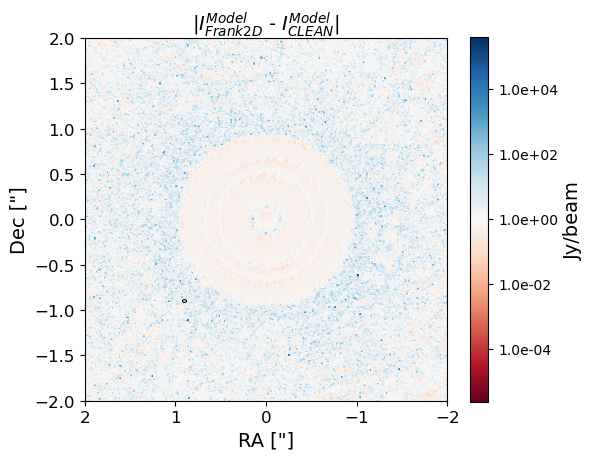

In [70]:
diff = np.abs((I_f2d_Jybeam_conv - img)/img)

#import LogNorm from matplotlib.colors
from matplotlib.colors import LogNorm

plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.4, vmin=diff.min(), vmax = diff.max())
norm = LogNorm(vmin=diff.min(), vmax=diff.max())

ax = plt.gca()

im = ax.imshow(
    diff,
    extent=[xmin, xmax, ymax, ymin],
    aspect='equal',
    cmap='RdBu',
    norm=norm,
)

ax.set_xlabel('RA ["]', size=14)
ax.set_ylabel('Dec ["]', size=14)
ax.set_xlim(xmax/1.5, xmin/1.5)
ax.set_ylim(ymax/1.5, ymin/1.5)
ax.set_title(r'|$I_{Frank2D}^{Model}$ - $I_{CLEAN}^{Model}$|', size=14)


cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label('Jy/beam', size =14)
cbar.formatter = FuncFormatter(lambda x, pos: f"{x:.1e}")
cbar.update_ticks()
ax.grid(False)


beam = patches.Ellipse(
    (0.9, -0.9), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)
plt.tick_params(axis='both', labelsize=12)


plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [71]:
np.median(diff)

1.013609383127323

## 1D Profile

In [72]:
f2d = frank2d
geom = geom_f2d
inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

In [73]:
from gofish import imagecube
cube_1mm = imagecube(fits_name)
x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [74]:
beam_frank2d = {'bmaj': FWHM_frank2d, 'bmin': FWHM_frank2d, 'beam_pa': 0}
beam_clean = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': hdr['BPA']}
final_beam_f2d = calculate_resolution2( beam_clean, beam_frank2d)

In [75]:
fits_image = fits.open(fits_name)
header = fits_image[0].header
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
area = clean_area
print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

beam_for_f2d = calculate_resolution(clean_beam, FWHM_frank2d)
beam_for_f2d = final_beam_f2d

Clean beam: 0.044606443494563996 x 0.0300071798264988 arcsec
-> Final beam to convolve with: 0.038219560453172804 x 0.01927254111786602 arcsec


In [76]:
# f2d model
u_model = f2d.u_grid
v_model = f2d.v_grid
vis_model = f2d.visibility_model

u_model_1d = f2d.u
v_model_1d = f2d.v

x_model = f2d.x_grid * rad_to_arcsec
y_model = f2d.y_grid * rad_to_arcsec

x_model_1d = f2d.x * rad_to_arcsec
y_model_1d = f2d.y * rad_to_arcsec

        
# phase shift
vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
I = f2d.transform(vis).real

# deproject
x_model, y_model = geom.deproject_xy(x_model, y_model)
x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

# collocation points for the plot.
r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
bins = 800
r = np.linspace(r.min(), r.max(), bins)
edges_ = edges(r)


r_model_1d, I_model_1d = get_profile(x_model, y_model, I, bins = edges_)
I_model_1d = np.nan_to_num(I_model_1d, nan=0)

In [77]:
from frank.utilities import convolve_profile
I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
I_model_1d_convolved *= area # Jy/beam

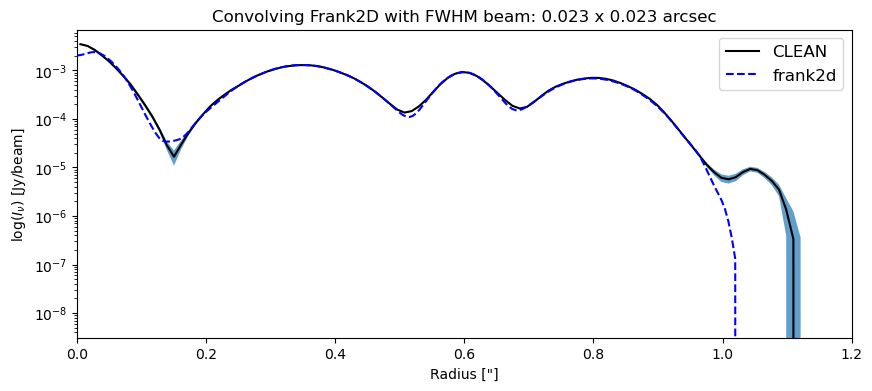

In [78]:
plt.figure(figsize=(10,4))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')

plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.title(f'Convolving Frank2D with FWHM beam: {FWHM_frank2d:.3f} x {FWHM_frank2d:.3f} arcsec')
plt.xlim(0, 1.2)
#plt.ylim(1e-7, 0.5e-2)
plt.show()

### Let's include F1D

##### load

In [84]:
import pickle

path_f1d = "../../data/f1d/f1d_Simulated_N300_rout3_alpha1p05_ws0p0001.pickle"

# Abrir y cargar el objeto
with open(path_f1d, 'rb') as f:   # 'rb' = read binary
    f1d = pickle.load(f)

##### save

In [80]:
u_f1d, v_f1d =  uvtable['u'], uvtable['v']
vis_f1d = uvtable['vis']
weights_f1d = uvtable['weights']

In [81]:
# Frank 1D parameters
n_pts = 300
alpha = 1.05
w_smooth = 1e-4
r_out = 3/2 * Rmax

from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter


geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, vis_f1d, weights_f1d)


ValueError: ERROR: Last collocation point, 6.870e+06 \lambda, is at a shorter baseline than the longest deprojected baseline in the dataset, 8.828e+06 \lambda. Please increase N in FrankMultFrequencyFitter (this is `hyperparameters: n` if you're using a parameter file). Or if you'd like to fit to shorter maximum baseline, cut the (u, v) distribution before fitting (`modify_data: baseline_range` in the parameter file).

#### compare

In [85]:
FWHM_frank1d = 14.7e-3

beam_frank1d = {'bmaj': FWHM_frank1d, 'bmin': FWHM_frank1d, 'beam_pa': 0}
final_beam_f1d = calculate_resolution( clean_beam, beam_frank1d)

TypeError: unsupported operand type(s) for ** or pow(): 'dict' and 'int'

In [86]:
r_f1d = f1d.r
I_f1d = f1d.mean
I_f1d_convolved = convolve_profile(r_f1d[1:], I_f1d[1:], inc, pa, final_beam_f1d)
I_f1d_convolved *= area # Jy/beam

NameError: name 'final_beam_f1d' is not defined

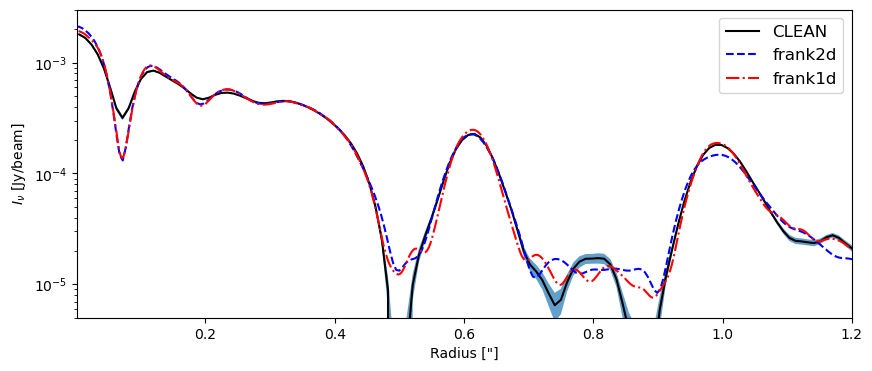

In [221]:
plt.figure(figsize=(10,4))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')
# frank1D -------------------------------------------------------------------
plt.plot(r_f1d[1:], I_f1d_convolved, color = 'red',ls ='-.', label = r'frank1d')

plt.ylabel(r'$I_\nu$ [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.title(f'')
plt.xlim(0.001, rout/2)
plt.ylim(5e-6, 3e-3)
plt.show()